In [ ]:
import urllib.request

urllib.request.urlretrieve(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXMXUS',
    '/content/DEXMXUS.csv'
)
print('Dataset descargado correctamente.')

Dataset descargado correctamente.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/DEXMXUS.csv')
print("Columnas:", df.columns.tolist())
df.head()

Columnas: ['observation_date', 'DEXMXUS']


,observation_date,DEXMXUS
0,1993-11-08,3.152
1,1993-11-09,3.240
2,1993-11-10,3.240
3,1993-11-11,NaN
4,1993-11-12,3.240


In [ ]:
# FRED usa '.' para valores faltantes — convertir a NaN
df['DEXMXUS'] = pd.to_numeric(df['DEXMXUS'], errors='coerce')

# Convertir observation_date a datetime
df['observation_date'] = pd.to_datetime(df['observation_date'])

# Ordenar por fecha
df = df.sort_values('observation_date').reset_index(drop=True)

# Eliminar nulos (fines de semana / festivos sin cotización)
df = df.dropna().reset_index(drop=True)

df.head()


,observation_date,DEXMXUS
0,1993-11-08,3.152
1,1993-11-09,3.240
2,1993-11-10,3.240
3,1993-11-12,3.240
4,1993-11-15,3.215


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  8108 non-null   datetime64[ns]
 1   DEXMXUS           8108 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 126.8 KB


In [ ]:
fecha_inicio = df['observation_date'].min()
fecha_fin = df['observation_date'].max()
fecha_inicio, fecha_fin

(Timestamp('1993-11-08 00:00:00'), Timestamp('2026-03-13 00:00:00'))

In [ ]:
#extraemos los datos de dexmxus en formato de lista simple (Numpy) 1D.
serie = df['DEXMXUS'].values

In [ ]:
# 5. Normalizar
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() # crea un objeto normalizador vacío — aún no ha visto los datos
serie_scaled = scaler.fit_transform(serie.reshape(-1, 1))#escala los valores de -1 y 1

In [ ]:
def create_dataset(series, n_steps):#transforma la serie temporal en pares de entrada/salida para el modelo
    X, y = [], []#listas vacías
    for i in range(len(series) - n_steps):#itera desde 0 hasta N-30. Se resta n_steps porque la última ventana termina en el último elemento
        X.append(series[i:i+n_steps])#extrae 30 valores consecutivos desde la posición i. Esto es la ventana de entrada.
        y.append(series[i+n_steps])#captura el valor inmediatamente después de la ventana. Esto es el objetivo a predecir.
    return np.array(X), np.array(y)#convierte las listas a arreglos numpy más eficientes.

n_steps = 30  # ventana de 30 días

X, y = create_dataset(serie_scaled, n_steps)
#se entrena con pasos de 30, cada ventana tiene 30 pasos  para que el modelo aprenda a relacionar los valores de la serie

In [ ]:
split = int(0.7 * len(X)) # Calcula el índice para el 70% de los datos.

# Divide los datos: el primer 70% para entrenar, el 30% final para evaluar.
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]



In [ ]:
X_train.shape

(5654, 30, 1)

In [ ]:
# "Aplana" los datos. Un MLP necesita una lista simple de 30 números por entrada en 2D,
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_test_mlp = X_test.reshape(X_test.shape[0], -1)

In [ ]:
X_train_mlp.shape

(5654, 30)

In [ ]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),#primera capa
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):#define cómo fluyen los datos al hacer una predicción
        return self.model(x)#x pasa por todas las capas de self.model

In [ ]:
def train_mlp(model, X_train, y_train, X_test, y_test, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#que tan grande son los ajustes en cada peso
    criterion = nn.MSELoss()#funcion de perdida

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()

        X_t = torch.tensor(X_train, dtype=torch.float32)
        y_t = torch.tensor(y_train, dtype=torch.float32)

        optimizer.zero_grad()
        pred = model(X_t)#pasa X_t por todas las capas y obtiene predicciones
        loss = criterion(pred, y_t)#calcula el MSE entre predicciones y valores reales
        loss.backward()#calcula la contribucion en cada peso al error total
        optimizer.step()# actualiza los pesos usando los gradientes calculados: w_nuevo = w_anterior - lr × gradiente

        model.eval()
        with torch.no_grad():#desactiva el cálculo de gradientes
            X_val = torch.tensor(X_test, dtype=torch.float32)
            y_val = torch.tensor(y_test, dtype=torch.float32)
            val_pred = model(X_val)#El modelo toma los datos de entrada que no se usaron para entrenar (X_val) y genera sus propias predicciones
            val_loss = criterion(val_pred, y_val)#Compara las predicciones del modelo (val_pred) contra las respuestas reales de validación (y_val) usando el criterio de error (MSE)

        train_losses.append(loss.item())
        test_losses.append(val_loss.item())

        print(f"Epoch {epoch+1}, Loss: {loss.item():.5f}, Val: {val_loss.item():.5f}")

    return train_losses, test_losses

In [ ]:
input_size = X_train_mlp.shape[1]#calcula el tamnio de cada ejemplo Si tu ventana es de 30 días, input_size será 30.
mlp = MLP(input_size)#Crea el objeto de la red neuronal pasando el tamaño de entrada que acabamos de calcular

train_loss_mlp, test_loss_mlp = train_mlp(
    mlp, X_train_mlp, y_train, X_test_mlp, y_test
)#llamamos a la funcion de entrenamiento y pasamos los parametros

Epoch 1, Loss: 0.13428, Val: 0.47075
Epoch 2, Loss: 0.11221, Val: 0.39244
Epoch 3, Loss: 0.09230, Val: 0.31959
Epoch 4, Loss: 0.07373, Val: 0.25190
Epoch 5, Loss: 0.05655, Val: 0.18897
Epoch 6, Loss: 0.04106, Val: 0.13412
Epoch 7, Loss: 0.02766, Val: 0.08944
Epoch 8, Loss: 0.01710, Val: 0.05298
Epoch 9, Loss: 0.00900, Val: 0.02672
Epoch 10, Loss: 0.00367, Val: 0.00952
Epoch 11, Loss: 0.00113, Val: 0.00152
Epoch 12, Loss: 0.00112, Val: 0.00132
Epoch 13, Loss: 0.00305, Val: 0.00587
Epoch 14, Loss: 0.00583, Val: 0.01164
Epoch 15, Loss: 0.00833, Val: 0.01582
Epoch 16, Loss: 0.00956, Val: 0.01611
Epoch 17, Loss: 0.00931, Val: 0.01247
Epoch 18, Loss: 0.00785, Val: 0.00753
Epoch 19, Loss: 0.00563, Val: 0.00305
Epoch 20, Loss: 0.00334, Val: 0.00069


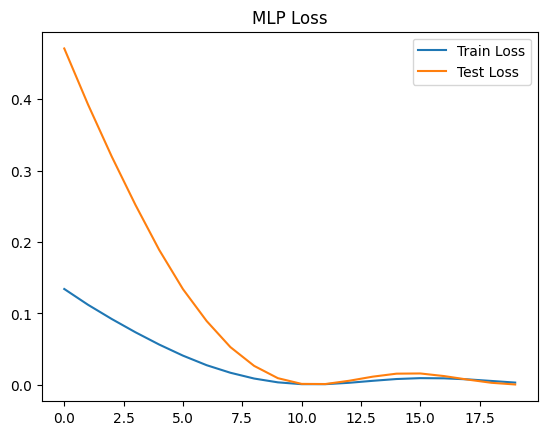

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss_mlp, label="Train Loss")
plt.plot(test_loss_mlp, label="Test Loss")
plt.legend()
plt.title("MLP Loss")
plt.show()

los valores del dataset son muy inestables o cambios bruscos en los datos que el modelo ya estaba esperando otro patron tienda a subir la perdida en ese momento

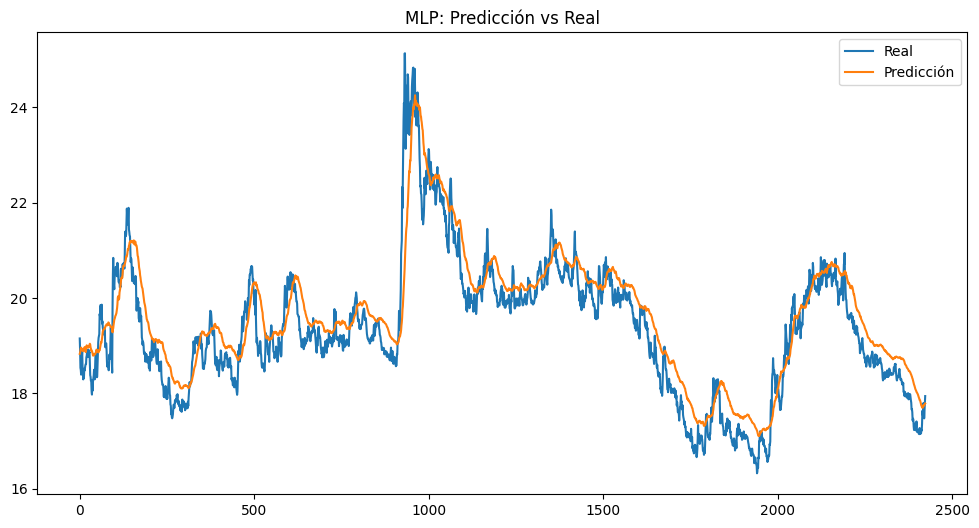

In [ ]:
mlp.eval()

with torch.no_grad():
    preds = mlp(torch.tensor(X_test_mlp, dtype=torch.float32)).numpy()

# Desnormalizar
y_test_inv = scaler.inverse_transform(y_test)
preds_inv = scaler.inverse_transform(preds)

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(preds_inv, label="Predicción")
plt.legend()
plt.title("MLP: Predicción vs Real")
plt.show()

El modelo logra predecir los puntos con bastante presicion

 x:cantidad de puntos/precios, y:anios de 2016 a 2024